Saved: carbon_price_sensitivity.pdf  &  carbon_price_sensitivity.png


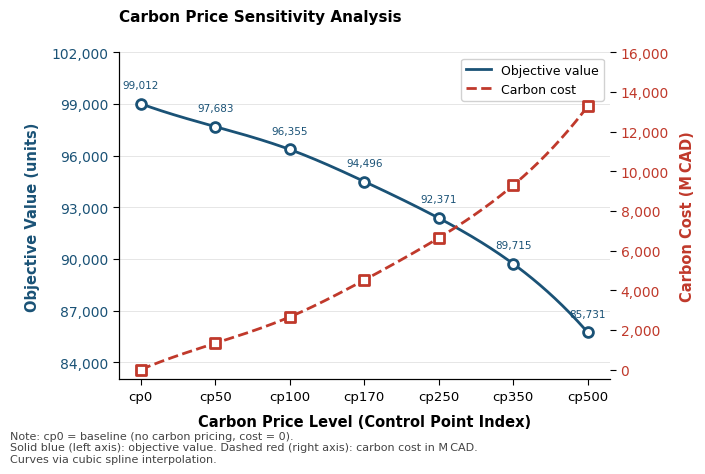

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy.interpolate import make_interp_spline

# --- Data ---
labels      = ['cp0', 'cp50', 'cp100', 'cp170', 'cp250', 'cp350', 'cp500']
x_num       = np.array([0, 50, 100, 170, 250, 350, 500])
y_obj       = np.array([99011.678, 97683.458, 96355.363,
                        94496.030, 92371.078, 89714.888, 85730.602])
y_cost      = np.array([0, 1328.095, 2656.190, 4515.523,
                        6640.476, 9296.666, 13280.951])

# --- Smooth splines ---
x_smooth    = np.linspace(x_num.min(), x_num.max(), 300)
obj_smooth  = make_interp_spline(x_num, y_obj,  k=3)(x_smooth)
cost_smooth = make_interp_spline(x_num, y_cost, k=3)(x_smooth)

# --- Style ---
matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
})

COLOR_OBJ  = '#1a5276'
COLOR_COST = '#C0392B'

# --- Figure ---
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color(COLOR_COST)

# Map numeric x to evenly-spaced positions for plotting
# but label them with cp labels
x_pos = np.linspace(0, len(labels) - 1, 300)
x_pts = np.arange(len(labels))

# Refit splines on index positions
obj_smooth_i  = make_interp_spline(x_pts, y_obj,  k=3)(x_pos)
cost_smooth_i = make_interp_spline(x_pts, y_cost, k=3)(x_pos)

# --- Smooth curves ---
ax1.plot(x_pos, obj_smooth_i,
         color=COLOR_OBJ, linewidth=2.0,
         label='Objective value', zorder=3)

ax2.plot(x_pos, cost_smooth_i,
         color=COLOR_COST, linewidth=2.0,
         linestyle='--', label='Carbon cost', zorder=3)

# --- Data points ---
ax1.scatter(x_pts, y_obj,
            s=50, zorder=5,
            facecolors='white', edgecolors=COLOR_OBJ, linewidths=2)

ax2.scatter(x_pts, y_cost,
            s=50, zorder=5, marker='s',
            facecolors='white', edgecolors=COLOR_COST, linewidths=2)

# --- Annotate objective value points ---
for i, yi in enumerate(y_obj):
    ax1.annotate('{:,.0f}'.format(yi),
                 xy=(i, yi), xytext=(0, 10),
                 textcoords='offset points',
                 ha='center', va='bottom',
                 fontsize=7.5, color=COLOR_OBJ)

# --- Axes ---
ax1.set_xticks(x_pts)
ax1.set_xticklabels(labels, fontsize=9.5)
ax1.set_xlabel('Carbon Price Level (Control Point Index)',
               fontsize=10.5, labelpad=8, fontweight='bold')

ax1.set_ylabel('Objective Value (units)',
               fontsize=10.5, labelpad=8,
               fontweight='bold', color=COLOR_OBJ)
ax2.set_ylabel('Carbon Cost (M\u202fCAD)',
               fontsize=10.5, labelpad=8,
               fontweight='bold', color=COLOR_COST)

ax1.tick_params(axis='y', labelcolor=COLOR_OBJ)
ax2.tick_params(axis='y', labelcolor=COLOR_COST)

ax1.set_ylim(83000, 102000)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: '{:,.0f}'.format(int(v))))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(3000))

ax2.set_ylim(-500, 16000)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: '{:,.0f}'.format(int(v))))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(2000))

ax1.grid(axis='y', color='grey', linewidth=0.4, linestyle='-', alpha=0.35)
ax1.set_axisbelow(True)

# --- Legend ---
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2,
           fontsize=9, frameon=True, framealpha=0.9,
           edgecolor='#cccccc', loc='upper right')

# --- Title ---
ax1.set_title('Carbon Price Sensitivity Analysis\n',
              fontsize=11, fontweight='bold', loc='left', pad=10)

# --- Caption ---
fig.text(0.0, -0.04,
         'Note: cp0 = baseline (no carbon pricing, cost = 0).\n'
         'Solid blue (left axis): objective value. Dashed red (right axis): carbon cost in M\u202fCAD.\n'
         'Curves via cubic spline interpolation.',
         fontsize=8, color='#444444')

plt.tight_layout()

fig.savefig('carbon_price_sensitivity.pdf', dpi=300, bbox_inches='tight')
fig.savefig('carbon_price_sensitivity.png', dpi=300, bbox_inches='tight',
            facecolor='white')

print("Saved: carbon_price_sensitivity.pdf  &  carbon_price_sensitivity.png")
plt.show()

Saved: carbon_price_sensitivity.pdf  &  carbon_price_sensitivity.png


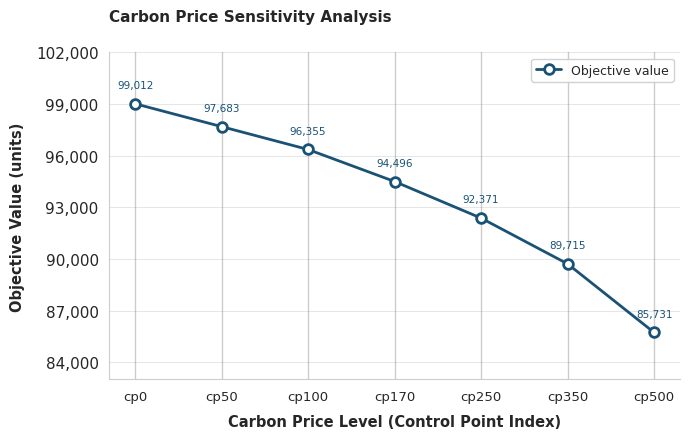

In [11]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- Data ---
labels = ['cp0', 'cp50', 'cp100', 'cp170', 'cp250', 'cp350', 'cp500']
x_idx  = np.array([0, 50, 100, 170, 250, 350, 500])   # numeric x for trend line
y      = np.array([99011.678, 97683.458, 96355.363,
                   94496.030, 92371.078, 89714.888, 85730.602])

# --- Style: publication-grade ---
matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'pdf.fonttype':      42,   # embeds fonts for Overleaf/PDF
    'ps.fonttype':       42,
})

# --- Figure ---
fig, ax = plt.subplots(figsize=(7, 4.5))   # ~double-column width in inches

# Main series
ax.plot(range(len(labels)), y,
        color='#1a5276', linewidth=2.0,
        marker='o', markersize=7,
        markerfacecolor='white', markeredgecolor='#1a5276', markeredgewidth=2,
        label='Objective value', zorder=3)

# Annotate each point
for i, (xi, yi) in enumerate(zip(range(len(labels)), y)):
    ax.annotate(f'{yi:,.0f}',
                xy=(xi, yi),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=7.5, color='#1a5276')

# --- Axes ---
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9.5)
ax.set_xlabel('Carbon Price Level (Control Point Index)',
              fontsize=10.5, labelpad=8, fontweight='bold')
ax.set_ylabel('Objective Value (units)',
              fontsize=10.5, labelpad=8, fontweight='bold')

ax.set_ylim(83000, 102000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(3000))

ax.grid(axis='y', color='grey', linewidth=0.4, linestyle='-', alpha=0.35)
ax.set_axisbelow(True)

# --- Title ---
ax.set_title('Carbon Price Sensitivity Analysis\n',
             fontsize=11, fontweight='bold', loc='left', pad=10)

# --- Legend ---
legend = ax.legend(fontsize=9, frameon=True, framealpha=0.9,
                   edgecolor='#cccccc', loc='upper right')

plt.tight_layout()

# --- Save ---
# For Overleaf: PDF preserves vector quality (recommended)
fig.savefig('carbon_price_sensitivity.pdf', dpi=300, bbox_inches='tight')

# PNG fallback (300 dpi is print-quality)
fig.savefig('carbon_price_sensitivity.png', dpi=300, bbox_inches='tight',
            facecolor='white')

print("Saved: carbon_price_sensitivity.pdf  &  carbon_price_sensitivity.png")
plt.show()

In [4]:
pip install scipy

Saved: carbon_price_sensitivity.pdf  &  carbon_price_sensitivity.png


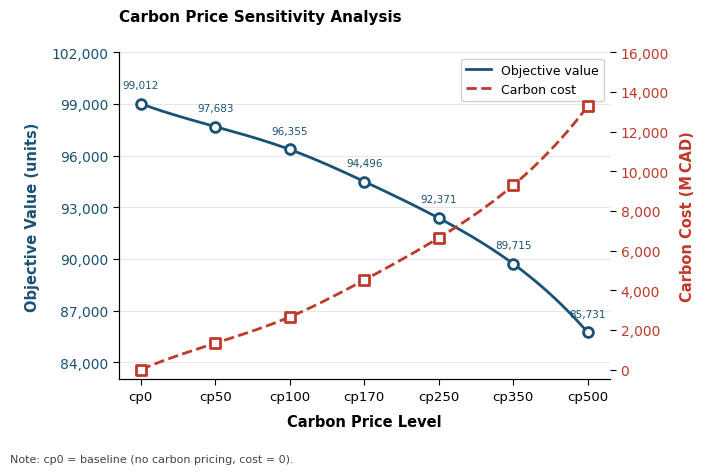

In [17]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy.interpolate import make_interp_spline

# --- Data ---
labels      = ['cp0', 'cp50', 'cp100', 'cp170', 'cp250', 'cp350', 'cp500']
x_num       = np.array([0, 50, 100, 170, 250, 350, 500])
y_obj       = np.array([99011.678, 97683.458, 96355.363,
                        94496.030, 92371.078, 89714.888, 85730.602])
y_cost      = np.array([0, 1328.095, 2656.190, 4515.523,
                        6640.476, 9296.666, 13280.951])

# --- Smooth splines ---
x_smooth    = np.linspace(x_num.min(), x_num.max(), 300)
obj_smooth  = make_interp_spline(x_num, y_obj,  k=3)(x_smooth)
cost_smooth = make_interp_spline(x_num, y_cost, k=3)(x_smooth)

# --- Style ---
matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
})

COLOR_OBJ  = '#1a5276'
COLOR_COST = '#C0392B'

# --- Figure ---
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color(COLOR_COST)

# Map numeric x to evenly-spaced positions for plotting
# but label them with cp labels
x_pos = np.linspace(0, len(labels) - 1, 300)
x_pts = np.arange(len(labels))

# Refit splines on index positions
obj_smooth_i  = make_interp_spline(x_pts, y_obj,  k=3)(x_pos)
cost_smooth_i = make_interp_spline(x_pts, y_cost, k=3)(x_pos)

# --- Smooth curves ---
ax1.plot(x_pos, obj_smooth_i,
         color=COLOR_OBJ, linewidth=2.0,
         label='Objective value', zorder=3)

ax2.plot(x_pos, cost_smooth_i,
         color=COLOR_COST, linewidth=2.0,
         linestyle='--', label='Carbon cost', zorder=3)

# --- Data points ---
ax1.scatter(x_pts, y_obj,
            s=50, zorder=5,
            facecolors='white', edgecolors=COLOR_OBJ, linewidths=2)

ax2.scatter(x_pts, y_cost,
            s=50, zorder=5, marker='s',
            facecolors='white', edgecolors=COLOR_COST, linewidths=2)

# --- Annotate objective value points ---
for i, yi in enumerate(y_obj):
    ax1.annotate('{:,.0f}'.format(yi),
                 xy=(i, yi), xytext=(0, 10),
                 textcoords='offset points',
                 ha='center', va='bottom',
                 fontsize=7.5, color=COLOR_OBJ)

# --- Axes ---
ax1.set_xticks(x_pts)
ax1.set_xticklabels(labels, fontsize=9.5)
ax1.set_xlabel('Carbon Price Level',
               fontsize=10.5, labelpad=8, fontweight='bold')

ax1.set_ylabel('Objective Value (units)',
               fontsize=10.5, labelpad=8,
               fontweight='bold', color=COLOR_OBJ)
ax2.set_ylabel('Carbon Cost (M\u202fCAD)',
               fontsize=10.5, labelpad=8,
               fontweight='bold', color=COLOR_COST)

ax1.tick_params(axis='y', labelcolor=COLOR_OBJ)
ax2.tick_params(axis='y', labelcolor=COLOR_COST)

ax1.set_ylim(83000, 102000)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: '{:,.0f}'.format(int(v))))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(3000))

ax2.set_ylim(-500, 16000)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: '{:,.0f}'.format(int(v))))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(2000))

ax1.grid(axis='y', color='grey', linewidth=0.4, linestyle='-', alpha=0.35)
ax1.set_axisbelow(True)

# --- Legend ---
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2,
           fontsize=9, frameon=True, framealpha=0.9,
           edgecolor='#cccccc', loc='upper right')

# --- Title ---
ax1.set_title('Carbon Price Sensitivity Analysis\n',
              fontsize=11, fontweight='bold', loc='left', pad=10)

# --- Caption ---
fig.text(0.0, -0.04,
         'Note: cp0 = baseline (no carbon pricing, cost = 0). ',
         fontsize=8, color='#444444')

plt.tight_layout()

fig.savefig('carbon_price_sensitivity.pdf', dpi=300, bbox_inches='tight')
fig.savefig('carbon_price_sensitivity.png', dpi=300, bbox_inches='tight',
            facecolor='white')

print("Saved: carbon_price_sensitivity.pdf  &  carbon_price_sensitivity.png")
plt.show()

In [10]:
pip install -U kaleido

Saved.


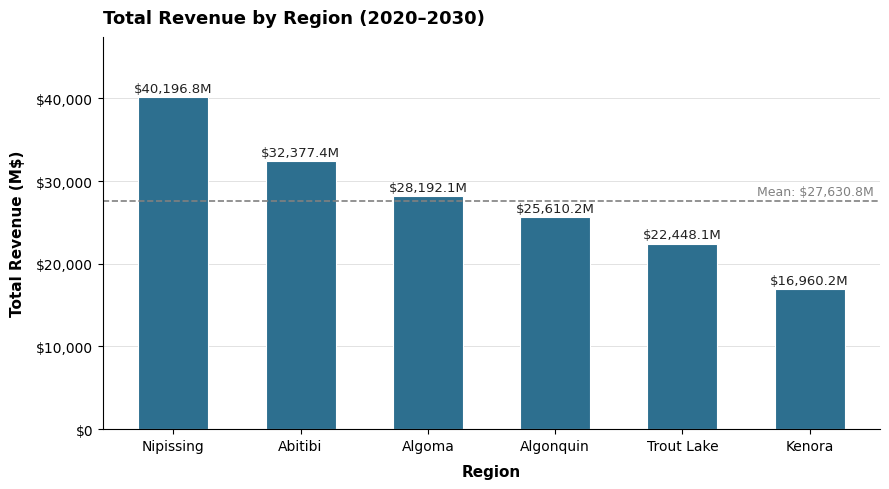

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
regions = ['Trout Lake', 'Abitibi', 'Algoma', 'Kenora', 'Nipissing', 'Algonquin']
revenue = [22448.108, 32377.445, 28192.127, 16960.216, 40196.803, 25610.201]

# Sort descending
pairs   = sorted(zip(revenue, regions), reverse=True)
revenue_s = [p[0] for p in pairs]
regions_s = [p[1] for p in pairs]

mean = sum(revenue) / len(revenue)

# --- Style ---
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth']  = 0.8
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['ps.fonttype']     = 42

# --- Figure ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

bars = ax.bar(regions_s, revenue_s,
              color='#2D6F8F', width=0.55, edgecolor='white', linewidth=0.8)

# Value labels on top of bars
for bar, val in zip(bars, revenue_s):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 250,
            '${:,.1f}M'.format(val),
            ha='center', va='bottom',
            fontsize=9.5, color='#222')

# Mean reference line
ax.axhline(mean, color='gray', linewidth=1.2, linestyle='--')
ax.text(len(regions_s) - 0.5, mean + 300,
        'Mean: ${:,.1f}M'.format(mean),
        ha='right', va='bottom',
        fontsize=9, color='gray')

# Axes
ax.set_ylabel('Total Revenue (M$)', fontsize=11, fontweight='bold', labelpad=8)
ax.set_xlabel('Region', fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylim(0, max(revenue_s) * 1.18)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: '${:,.0f}'.format(int(x)))
)
ax.grid(axis='y', color='grey', linewidth=0.4, alpha=0.4)
ax.set_axisbelow(True)

ax.set_title('Total Revenue by Region (2020\u20132030)',
             fontsize=13, fontweight='bold', loc='left', pad=10)

plt.tight_layout()

fig.savefig('revenue_by_region.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('revenue_by_region.pdf', bbox_inches='tight')

print('Saved.')
plt.show()

Saved.


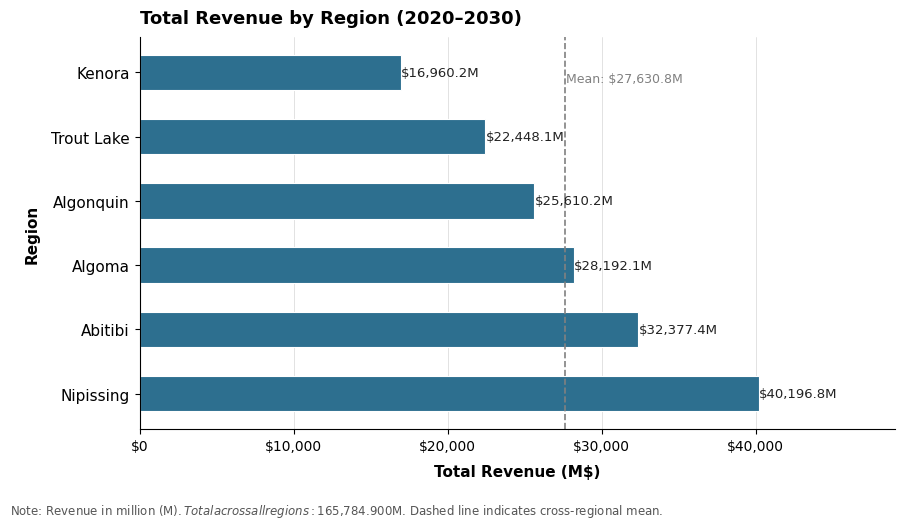

In [21]:
import matplotlib.pyplot as plt

# --- Data ---

regions = ['Trout Lake', 'Abitibi', 'Algoma', 'Kenora', 'Nipissing', 'Algonquin']
revenue = [22448.108, 32377.445, 28192.127, 16960.216, 40196.803, 25610.201]


# Sort descending
pairs     = sorted(zip(revenue, regions), reverse=True)
revenue_s = [p[0] for p in pairs]
regions_s = [p[1] for p in pairs]

mean  = sum(revenue) / len(revenue)
total = sum(revenue)

# --- Style ---
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth']  = 0.8
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['ps.fonttype']     = 42

# --- Figure ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

bars = ax.barh(regions_s, revenue_s,
               color='#2D6F8F', height=0.55,
               edgecolor='white', linewidth=0.8)

# Value labels at end of bars
for bar, val in zip(bars, revenue_s):
    ax.text(val + 25,
            bar.get_y() + bar.get_height() / 2,
            '${:,.1f}M'.format(val),
            ha='left', va='center',
            fontsize=9.5, color='#222')

# Mean reference line
ax.axvline(mean, color='gray', linewidth=1.2, linestyle='--')
ax.text(mean + 25, len(regions_s) - 1,
        'Mean: ${:,.1f}M'.format(mean),
        ha='left', va='top',
        fontsize=9, color='gray')

# Axes
ax.set_xlabel('Total Revenue (M$)', fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel('Region', fontsize=11, fontweight='bold', labelpad=8)
ax.set_xlim(0, max(revenue_s) * 1.22)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: '${:,.0f}'.format(int(x)))
)
ax.grid(axis='x', color='grey', linewidth=0.4, alpha=0.4)
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=11)

ax.set_title('Total Revenue by Region (2020\u20132030)',
             fontsize=13, fontweight='bold', loc='left', pad=10)

fig.text(0.0, -0.04,
         'Note: Revenue in million (M$). '
         'Total across all regions: ${:,.3f}M. '
         'Dashed line indicates cross-regional mean.'.format(total),
         fontsize=8.5, color='#555')

plt.tight_layout()

fig.savefig('revenue_2025.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('revenue_2025.pdf', bbox_inches='tight')

print('Saved.')
plt.show()

Saved.


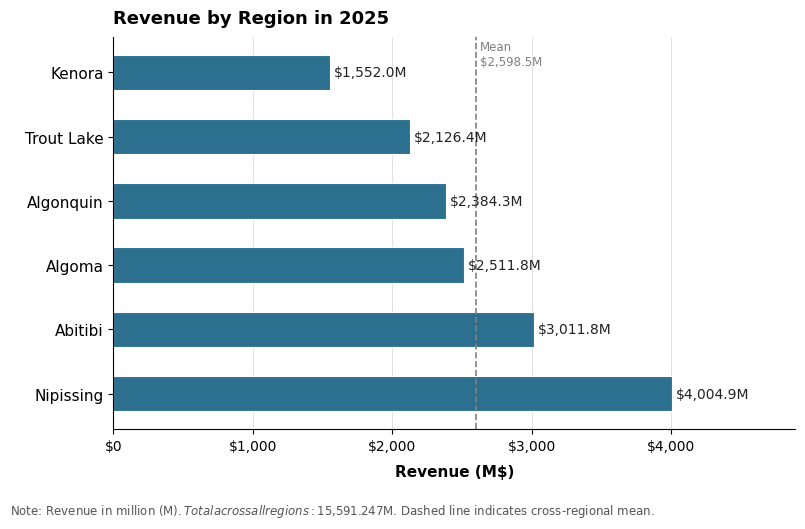

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
regions = ['Trout Lake', 'Abitibi', 'Algoma', 'Kenora', 'Nipissing', 'Algonquin']
revenue = [2126.382, 3011.830, 2511.838, 1551.985, 4004.901, 2384.311]

# Sort descending
pairs     = sorted(zip(revenue, regions), reverse=True)
revenue_s = [p[0] for p in pairs]
regions_s = [p[1] for p in pairs]

mean  = sum(revenue) / len(revenue)
total = sum(revenue)

# --- Style ---
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth']  = 0.8
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['ps.fonttype']     = 42

# --- Figure ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Horizontal bars
bars = ax.barh(regions_s, revenue_s,
               color='#2D6F8F', height=0.55,
               edgecolor='white', linewidth=0.8)

# Value labels
for bar, val in zip(bars, revenue_s):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            '${:,.1f}M'.format(val),
            va='center', ha='left', fontsize=10, color='#222')

# Mean line
ax.axvline(mean, color='gray', linewidth=1.2, linestyle='--')
ax.text(mean + 30, len(regions_s) - 0.5,
        'Mean\n${:,.1f}M'.format(mean),
        va='top', ha='left', fontsize=8.5, color='gray')

# Axes
ax.set_xlabel('Revenue (M$)', fontsize=11, fontweight='bold', labelpad=8)
ax.set_xlim(0, max(revenue_s) * 1.22)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: '${:,.0f}'.format(int(x)))
)
ax.grid(axis='x', color='grey', linewidth=0.4, alpha=0.4)
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=11)

ax.set_title('Revenue by Region in 2025',
             fontsize=13, fontweight='bold', loc='left', pad=10)

fig.text(0.0, -0.04,
         'Note: Revenue in million (M$). '
         'Total across all regions: ${:,.3f}M. '
         'Dashed line indicates cross-regional mean.'.format(total),
         fontsize=8.5, color='#555')

plt.tight_layout()

fig.savefig('revenue_2025.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('revenue_2025.pdf', bbox_inches='tight')

print('Saved.')
plt.show()

Saved.


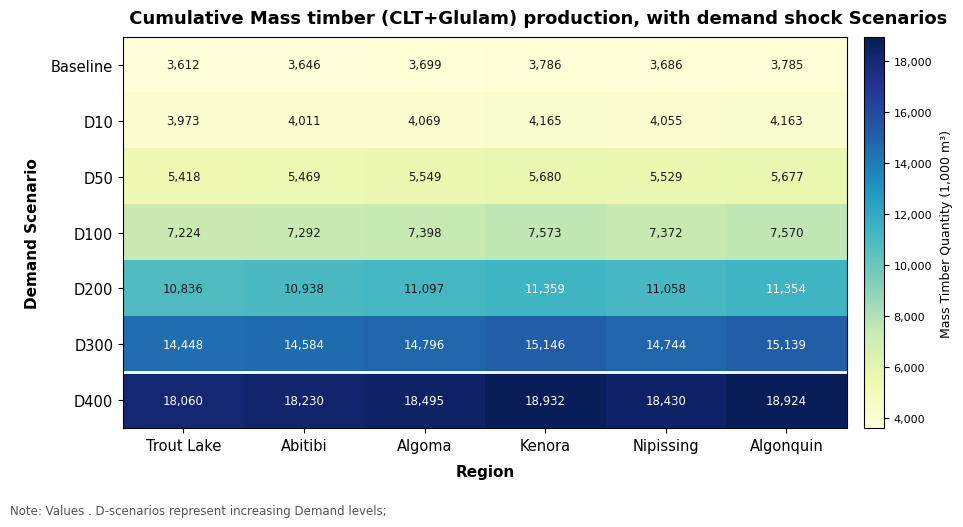

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# --- Data ---
scenarios = ['Baseline', 'D10', 'D50', 'D100', 'D200', 'D300', 'D400']
regions   = ['Trout Lake', 'Abitibi', 'Algoma', 'Kenora', 'Nipissing', 'Algonquin']

data = np.array([
    [3612.066,  3646.042,  3699.067,  3786.401,  3685.933,  3784.808],  # Baseline
    [3973.272,  4010.647,  4068.973,  4165.042,  4054.527,  4163.289],  # D10
    [5418.098,  5469.064,  5548.600,  5679.602,  5528.900,  5677.213],  # D50
    [7224.131,  7292.085,  7398.133,  7572.803,  7371.867,  7569.617],  # D100
    [10836.197, 10938.127, 11097.200, 11359.204, 11057.800, 11354.425], # D200
    [14448.262, 14584.169, 14796.267, 15145.606, 14743.733, 15139.234], # D300
    [18060.328, 18230.212, 18495.333, 18932.007, 18429.667, 18924.042], # D400
])

# --- Style ---
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth']  = 0.8
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['ps.fonttype']     = 42

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(data, cmap='YlGnBu', aspect='auto',
               vmin=data.min(), vmax=data.max())

# Axes ticks
ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions, fontsize=10.5)
ax.set_yticks(range(len(scenarios)))
ax.set_yticklabels(scenarios, fontsize=10.5)

# Annotate cells
thresh = (data.max() + data.min()) / 2
for i in range(len(scenarios)):
    for j in range(len(regions)):
        text_color = 'white' if data[i, j] > thresh else '#1a1a1a'
        ax.text(j, i, '{:,.0f}'.format(data[i, j]),
                ha='center', va='center',
                fontsize=8.5, color=text_color)

# Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.ax.set_ylabel('Mass Timber Quantity (1,000 m\u00b3)', fontsize=9, labelpad=6)
cbar.ax.tick_params(labelsize=8)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: '{:,.0f}'.format(int(x)))
)

# Separator line between D400 and DU10
ax.axhline(5.5, color='white', linewidth=2)

ax.set_title(' Cumulative Mass timber (CLT+Glulam) production, with demand shock Scenarios',
             fontsize=13, fontweight='bold', loc='left', pad=10)
ax.set_xlabel('Region', fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel('Demand Scenario', fontsize=11, fontweight='bold', labelpad=8)

fig.text(0.0, -0.04,
         'Note: Values . D-scenarios represent increasing Demand levels; '
,
         fontsize=8.5, color='#555')

plt.tight_layout()

fig.savefig('processing_cost_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('processing_cost_heatmap.pdf', bbox_inches='tight')

print('Saved.')
plt.show()

/tmp/ipykernel_7840/3533172763.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved.


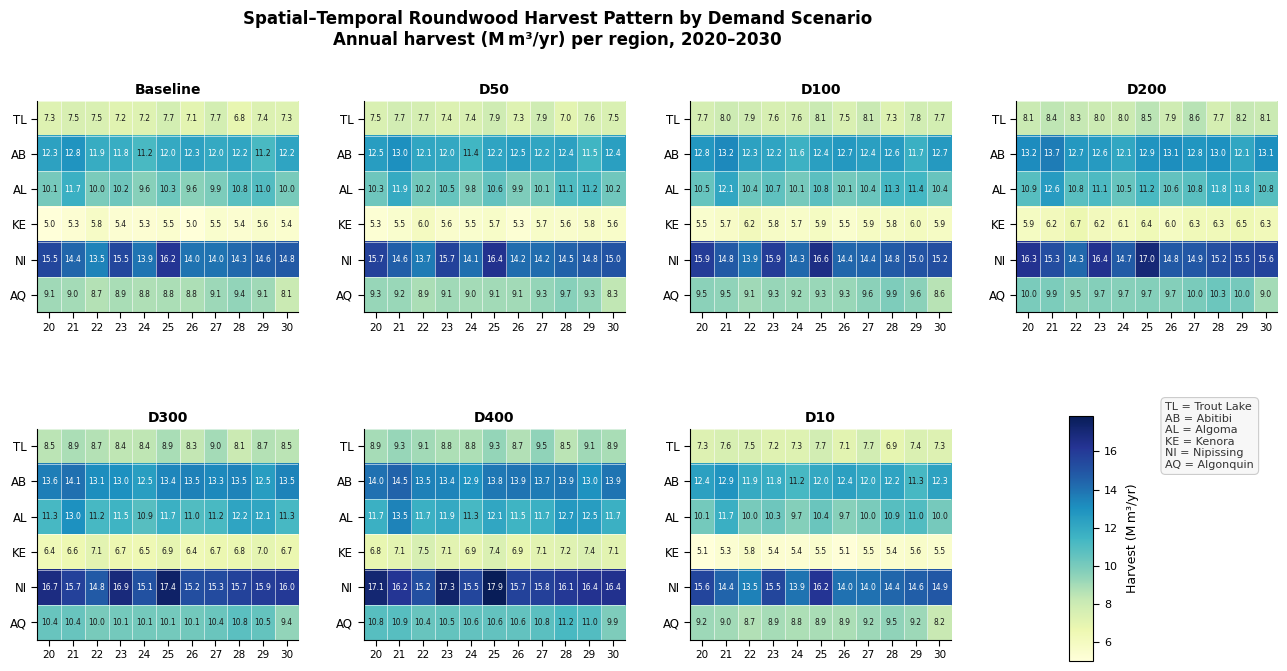

In [20]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- Data ---
years    = list(range(2020, 2031))
regions  = ['Trout Lake', 'Abitibi', 'Algoma', 'Kenora', 'Nipissing', 'Algonquin']
scenarios = ['Baseline', 'D50', 'D100', 'D200', 'D300', 'D400', 'D10']

data = {
    'Baseline': np.array([
        [7.261,7.507,7.455,7.168,7.242,7.708,7.067,7.700,6.842,7.356,7.270],
        [12.326,12.845,11.892,11.797,11.205,11.974,12.320,11.960,12.151,11.236,12.234],
        [10.068,11.671,9.951,10.241,9.646,10.332,9.621,9.913,10.836,10.982,10.004],
        [5.026,5.299,5.779,5.359,5.323,5.470,5.033,5.501,5.393,5.583,5.437],
        [15.549,14.392,13.486,15.464,13.908,16.186,13.956,13.966,14.320,14.601,14.837],
        [9.113,9.002,8.655,8.898,8.780,8.849,8.834,9.141,9.436,9.106,8.118],
    ]),
    'D50': np.array([
        [7.471,7.734,7.658,7.374,7.440,7.912,7.274,7.920,7.048,7.577,7.477],
        [12.538,13.048,12.098,12.001,11.419,12.204,12.517,12.179,12.368,11.453,12.443],
        [10.267,11.895,10.166,10.455,9.850,10.554,9.855,10.133,11.067,11.175,10.214],
        [5.253,5.520,5.999,5.575,5.523,5.709,5.262,5.702,5.620,5.811,5.646],
        [15.748,14.617,13.699,15.696,14.110,16.395,14.170,14.193,14.543,14.820,15.032],
        [9.329,9.236,8.878,9.102,9.005,9.063,9.051,9.347,9.661,9.340,8.337],
    ]),
    'D100': np.array([
        [7.681,7.960,7.862,7.580,7.638,8.117,7.481,8.141,7.254,7.797,7.685],
        [12.750,13.250,12.305,12.205,11.632,12.433,12.715,12.398,12.585,11.670,12.652],
        [10.465,12.118,10.382,10.668,10.055,10.777,10.089,10.353,11.298,11.367,10.424],
        [5.479,5.741,6.220,5.792,5.723,5.949,5.491,5.902,5.847,6.040,5.855],
        [15.947,14.842,13.912,15.927,14.311,16.604,14.384,14.419,14.765,15.039,15.226],
        [9.546,9.469,9.101,9.307,9.230,9.277,9.269,9.553,9.885,9.574,8.557],
    ]),
    'D200': np.array([
        [8.101,8.414,8.269,7.992,8.033,8.526,7.895,8.581,7.665,8.239,8.099],
        [13.175,13.656,12.717,12.614,12.059,12.893,13.110,12.835,13.018,12.103,13.070],
        [10.862,12.565,10.812,11.096,10.464,11.221,10.557,10.794,11.760,11.751,10.844],
        [5.932,6.183,6.661,6.225,6.123,6.428,5.950,6.303,6.302,6.497,6.273],
        [16.345,15.292,14.338,16.391,14.715,17.021,14.813,14.871,15.210,15.476,15.615],
        [9.979,9.936,9.546,9.715,9.680,9.704,9.705,9.965,10.334,10.042,8.996],
    ]),
    'D300': np.array([
        [8.522,8.867,8.676,8.404,8.429,8.935,8.310,9.022,8.077,8.680,8.513],
        [13.599,14.062,13.130,13.022,12.485,13.352,13.504,13.273,13.452,12.537,13.488],
        [11.259,13.012,11.242,11.523,10.873,11.666,11.025,11.234,12.222,12.135,11.263],
        [6.385,6.624,7.103,6.659,6.523,6.908,6.408,6.705,6.756,6.954,6.691],
        [16.744,15.742,14.764,16.854,15.118,17.439,15.241,15.324,15.655,15.913,16.004],
        [10.412,10.403,9.992,10.124,10.130,10.132,10.140,10.377,10.783,10.510,9.435],
    ]),
    'D400': np.array([
        [8.942,9.321,9.083,8.816,8.825,9.344,8.724,9.463,8.489,9.122,8.928],
        [14.024,14.468,13.543,13.430,12.912,13.812,13.899,13.710,13.885,12.971,13.906],
        [11.655,13.459,11.672,11.950,11.282,12.110,11.493,11.674,12.684,12.520,11.683],
        [6.839,7.066,7.544,7.092,6.923,7.387,6.866,7.106,7.210,7.411,7.109],
        [17.142,16.191,15.190,17.317,15.522,17.856,15.670,15.776,16.100,16.350,16.393],
        [10.846,10.869,10.437,10.533,10.580,10.559,10.575,10.789,11.232,10.978,9.874],
    ]),
    'D10': np.array([
        [7.303,7.552,7.496,7.209,7.281,7.749,7.108,7.744,6.883,7.400,7.312],
        [12.368,12.885,11.933,11.838,11.248,12.020,12.359,12.004,12.195,11.279,12.275],
        [10.108,11.716,9.994,10.284,9.687,10.377,9.668,9.957,10.882,11.021,10.046],
        [5.071,5.344,5.823,5.402,5.363,5.517,5.079,5.541,5.439,5.628,5.479],
        [15.588,14.437,13.528,15.511,13.948,16.228,13.999,14.012,14.364,14.645,14.876],
        [9.156,9.049,8.700,8.939,8.825,8.892,8.877,9.182,9.481,9.153,8.162],
    ]),
}

# --- Global color range across all scenarios ---
all_vals = np.concatenate([v.flatten() for v in data.values()])
vmin, vmax = all_vals.min(), all_vals.max()

# --- Style ---
matplotlib.rcParams.update({
    'font.family':    'sans-serif',
    'font.sans-serif':['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':      9,
    'pdf.fonttype':   42,
    'ps.fonttype':    42,
})

# --- Layout: 7 panels in 2 rows (4 + 3) ---
n_scen = len(scenarios)
ncols  = 4
nrows  = 2
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(16, 7),
                         gridspec_kw={'hspace': 0.55, 'wspace': 0.25})
axes = axes.flatten()

year_labels = [str(y) for y in years]
short_regions = ['TL', 'AB', 'AL', 'KE', 'NI', 'AQ']  # abbreviated for space

for idx, scen in enumerate(scenarios):
    ax  = axes[idx]
    mat = data[scen]                          # shape (6 regions, 11 years)

    im = ax.imshow(mat, cmap='YlGnBu',
                   aspect='auto',
                   vmin=vmin, vmax=vmax)

    # Ticks
    ax.set_xticks(range(len(years)))
    ax.set_xticklabels([str(y)[2:] for y in years],  # '20'..'30'
                       fontsize=7.5, rotation=0)
    ax.set_yticks(range(len(regions)))
    ax.set_yticklabels(short_regions, fontsize=8.5)

    ax.set_title(scen, fontsize=10, fontweight='bold', pad=5)

    # Annotate cells
    thresh = (vmin + vmax) / 2
    for r in range(len(regions)):
        for c in range(len(years)):
            val = mat[r, c]
            tc  = 'white' if val > thresh else '#1a1a1a'
            ax.text(c, r, '{:.1f}'.format(val),
                    ha='center', va='center',
                    fontsize=5.5, color=tc)

    # Light grid lines between cells
    ax.set_xticks(np.arange(-0.5, len(years),  1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(regions), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.4)
    ax.tick_params(which='minor', length=0)

# Hide the 8th panel (4×2 grid, only 7 scenarios)
axes[7].set_visible(False)

# --- Shared colorbar in the empty 8th slot ---
cbar_ax = fig.add_axes([0.77, 0.08, 0.015, 0.35])
sm = plt.cm.ScalarMappable(cmap='YlGnBu',
                            norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Harvest (M\u202fm\u00b3/yr)', fontsize=9, labelpad=6)
cbar.ax.tick_params(labelsize=8)

# --- Region legend ---
region_legend = '\n'.join(['TL = Trout Lake', 'AB = Abitibi',
                            'AL = Algoma',     'KE = Kenora',
                            'NI = Nipissing',  'AQ = Algonquin'])
fig.text(0.83, 0.45, region_legend,
         fontsize=8, va='top', color='#333',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#f7f7f7',
                   edgecolor='#cccccc',
                   linewidth=0.8))

# --- Overall title & note ---
fig.suptitle('Spatial–Temporal Roundwood Harvest Pattern by Demand Scenario\n'
             'Annual harvest (M\u202fm\u00b3/yr) per region, 2020–2030',
             fontsize=12, fontweight='bold', y=1.01, x=0.45)



plt.tight_layout()

fig.savefig('harvest_heatmap_faceted.png', dpi=300,
            bbox_inches='tight', facecolor='white')
fig.savefig('harvest_heatmap_faceted.pdf', bbox_inches='tight')

print('Saved.')
plt.show()

Saved: abm_coupling.pdf  &  abm_coupling.png


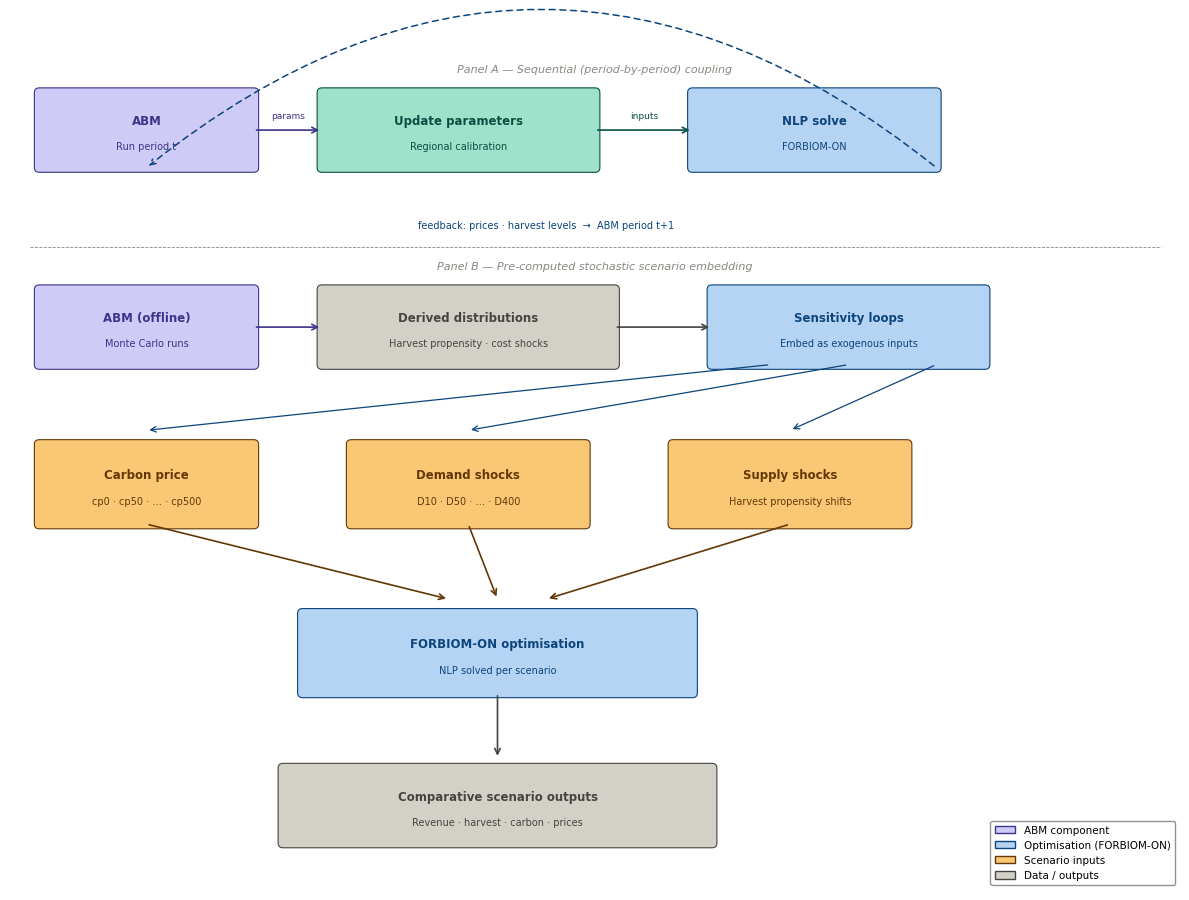

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# --- Style ---
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['ps.fonttype']     = 42

# --- Colors ---
C_PURPLE = '#CECBF6'
C_PURPLE_T = '#3C3489'
C_TEAL   = '#9FE1CB'
C_TEAL_T = '#085041'
C_BLUE   = '#B5D4F4'
C_BLUE_T = '#0C447C'
C_GRAY   = '#D3D1C7'
C_GRAY_T = '#444441'
C_AMBER  = '#FAC775'
C_AMBER_T= '#633806'
EDGE     = '#888780'

fig, ax = plt.subplots(figsize=(12, 9))
ax.set_xlim(0, 12)
ax.set_ylim(0, 9)
ax.axis('off')

# ── Helper functions ──────────────────────────────────────────────────

def box(ax, x, y, w, h, fc, ec, title, subtitle=None):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle='round,pad=0.05',
                          facecolor=fc, edgecolor=ec,
                          linewidth=0.8)
    ax.add_patch(rect)
    if subtitle:
        ax.text(x + w/2, y + h*0.62, title,
                ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=ec)
        ax.text(x + w/2, y + h*0.28, subtitle,
                ha='center', va='center',
                fontsize=7, color=ec)
    else:
        ax.text(x + w/2, y + h/2, title,
                ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=ec)

def arrow(ax, x1, y1, x2, y2, color, dashed=False):
    style = 'dashed' if dashed else 'solid'
    ls    = (0, (4, 3)) if dashed else 'solid'
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.2, linestyle=ls,
                                connectionstyle='arc3,rad=0.0'))

def label_on_arrow(ax, x, y, text, color):
    ax.text(x, y, text, ha='center', va='center',
            fontsize=6.5, color=color,
            bbox=dict(facecolor='white', edgecolor='none', pad=1))

# ═══════════════════════════════════════════════════════
# PANEL A — Sequential coupling loop
# ═══════════════════════════════════════════════════════

ax.text(6, 8.75, 'Panel A — Sequential (period-by-period) coupling',
        ha='center', va='center', fontsize=8, color=EDGE, style='italic')

# Boxes
box(ax, 0.3,  7.7, 2.2, 0.8, C_PURPLE, C_PURPLE_T, 'ABM',        'Run period t')
box(ax, 3.2,  7.7, 2.8, 0.8, C_TEAL,   C_TEAL_T,   'Update parameters', 'Regional calibration')
box(ax, 7.0,  7.7, 2.5, 0.8, C_BLUE,   C_BLUE_T,   'NLP solve',  'FORBIOM-ON')

# Forward arrows
arrow(ax, 2.5,  8.1, 3.2,  8.1, C_PURPLE_T)
label_on_arrow(ax, 2.85, 8.25, 'params', C_PURPLE_T)

arrow(ax, 6.0,  8.1, 7.0,  8.1, C_TEAL_T)
label_on_arrow(ax, 6.5, 8.25, 'inputs', C_TEAL_T)

# Feedback arc (dashed, below boxes)
ax.annotate('', xy=(1.4, 7.7), xytext=(9.5, 7.7),
            arrowprops=dict(arrowstyle='->', color=C_BLUE_T, lw=1.1,
                            linestyle=(0,(4,3)),
                            connectionstyle='arc3,rad=0.4'))
ax.text(5.5, 7.08, 'feedback: prices · harvest levels  →  ABM period t+1',
        ha='center', va='center', fontsize=7, color=C_BLUE_T)

# Divider
ax.plot([0.2, 11.8], [6.85, 6.85], color=EDGE, lw=0.6, ls='--')

# ═══════════════════════════════════════════════════════
# PANEL B — Pre-computed stochastic embedding
# ═══════════════════════════════════════════════════════

ax.text(6, 6.65, 'Panel B — Pre-computed stochastic scenario embedding',
        ha='center', va='center', fontsize=8, color=EDGE, style='italic')

# Row 1: ABM → distributions → sensitivity loops
box(ax, 0.3,  5.6, 2.2, 0.8, C_PURPLE, C_PURPLE_T, 'ABM (offline)',   'Monte Carlo runs')
box(ax, 3.2,  5.6, 3.0, 0.8, C_GRAY,   C_GRAY_T,   'Derived distributions', 'Harvest propensity · cost shocks')
box(ax, 7.2,  5.6, 2.8, 0.8, C_BLUE,   C_BLUE_T,   'Sensitivity loops', 'Embed as exogenous inputs')

arrow(ax, 2.5,  6.0, 3.2,  6.0, C_PURPLE_T)
arrow(ax, 6.2,  6.0, 7.2,  6.0, C_GRAY_T)

# Three branches from sensitivity loops down to scenario boxes
ax.annotate('', xy=(1.4,  4.9), xytext=(7.8, 5.6),
            arrowprops=dict(arrowstyle='->', color=C_BLUE_T, lw=0.9,
                            connectionstyle='arc3,rad=0.0'))
ax.annotate('', xy=(4.7,  4.9), xytext=(8.6, 5.6),
            arrowprops=dict(arrowstyle='->', color=C_BLUE_T, lw=0.9,
                            connectionstyle='arc3,rad=0.0'))
ax.annotate('', xy=(8.0,  4.9), xytext=(9.5, 5.6),
            arrowprops=dict(arrowstyle='->', color=C_BLUE_T, lw=0.9,
                            connectionstyle='arc3,rad=0.0'))

# Scenario boxes (row 2)
box(ax, 0.3,  3.9, 2.2, 0.85, C_AMBER, C_AMBER_T, 'Carbon price',    'cp0 · cp50 · … · cp500')
box(ax, 3.5,  3.9, 2.4, 0.85, C_AMBER, C_AMBER_T, 'Demand shocks',   'D10 · D50 · … · D400')
box(ax, 6.8,  3.9, 2.4, 0.85, C_AMBER, C_AMBER_T, 'Supply shocks',   'Harvest propensity shifts')

# Arrows from scenario boxes to FORBIOM
arrow(ax, 1.4,  3.9, 4.5, 3.1, C_AMBER_T)
arrow(ax, 4.7,  3.9, 5.0, 3.1, C_AMBER_T)
arrow(ax, 8.0,  3.9, 5.5, 3.1, C_AMBER_T)

# FORBIOM solve
box(ax, 3.0,  2.1, 4.0, 0.85, C_BLUE, C_BLUE_T, 'FORBIOM-ON optimisation', 'NLP solved per scenario')

# Output
arrow(ax, 5.0, 2.1, 5.0, 1.4, C_GRAY_T)
box(ax, 2.8,  0.5, 4.4, 0.8,  C_GRAY, C_GRAY_T, 'Comparative scenario outputs', 'Revenue · harvest · carbon · prices')

# ── Legend ─────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=C_PURPLE, edgecolor=C_PURPLE_T, label='ABM component'),
    mpatches.Patch(facecolor=C_BLUE,   edgecolor=C_BLUE_T,   label='Optimisation (FORBIOM-ON)'),
    mpatches.Patch(facecolor=C_AMBER,  edgecolor=C_AMBER_T,  label='Scenario inputs'),
    mpatches.Patch(facecolor=C_GRAY,   edgecolor=C_GRAY_T,   label='Data / outputs'),
]
ax.legend(handles=legend_items, loc='lower right',
          fontsize=7.5, framealpha=0.9,
          edgecolor=EDGE, fancybox=True)

plt.tight_layout()
fig.savefig('abm_coupling.pdf', dpi=300, bbox_inches='tight')
fig.savefig('abm_coupling.png', dpi=300, bbox_inches='tight', facecolor='white')
print('Saved: abm_coupling.pdf  &  abm_coupling.png')
plt.show()